In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://media.githubusercontent.com/media/suhani-pandey/Assignment1_SocialDataAnalysis/refs/heads/main/SF_Crime_Merged_FINAL_CLEAN_2003_2026.csv"
df = pd.read_csv(url, low_memory=False)
print(df.shape)


(2906890, 22)


In [2]:
# Normalize categories fully
df["cat_clean"] = (
    df["Incident Category"]
    .astype(str)
    .str.upper()
    .str.replace("/", " ", regex=False)
    .str.replace("  ", " ", regex=False)
    .str.strip()
)

focus_crimes = [
    "ASSAULT",
    "BURGLARY",
    "LARCENY THEFT",
    "MOTOR VEHICLE THEFT",
    "ROBBERY"
]



yearly = (
    df[df["cat_clean"].isin(focus_crimes)]
    .groupby(["year", "cat_clean"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Years in plot:", yearly.index.min(), "-", yearly.index.max())



Years in plot: 2003 - 2026


## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

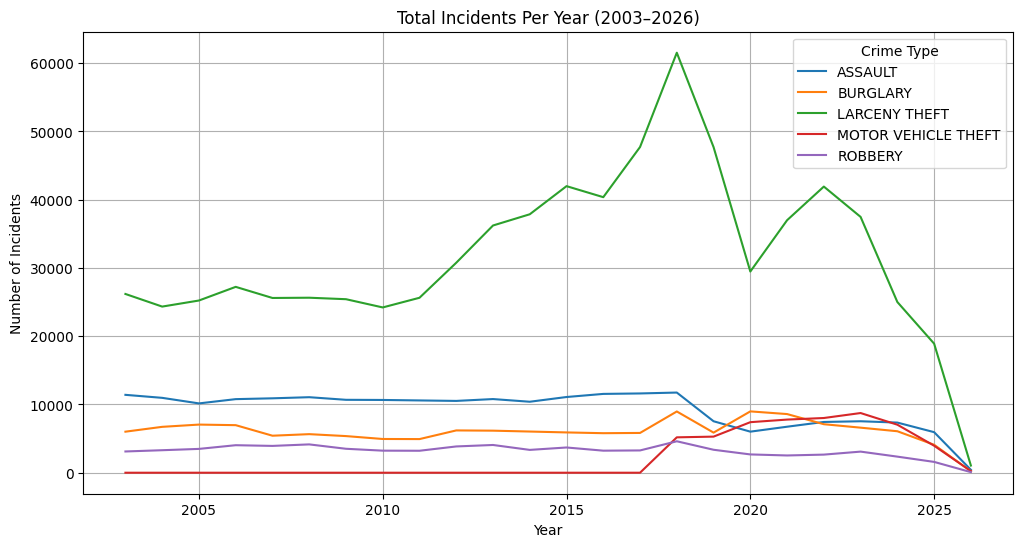

In [3]:

yearly.plot(figsize=(12,6))
plt.title("Total Incidents Per Year (2003–2026)")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.legend(title="Crime Type")
plt.grid(True)
plt.show()

#Excerise 1.1
The temporal trends from 2003 to 2025 reveal several important patterns across the selected focus crimes.
LONG-TERM TREND IN LARCENY THEFT ::
Larceny Theft is consistently the most frequent crime category throughout the entire period.It increases steadily from the early 2010s and peaks dramatically around 2017-2018,reaching over 60,000 incidents.After this peak,it declines sharply in 2020 before partially recovering and then decreasing again in recent years.The continued decline after 2023 may reflect changes in policing ,reporting practices ,or incomplete data for the most recent years.

COVID-19 IMPACT IN 2020::
Nearly all crime categories show a noticeable drop in 2020.This is especially visible in Larceny Theft and Assault.The timing strongly suggests the impact of the COVID-19 pandemic,when lockdown measures reduced public movement and social interaction.With fewer people in public spaces, opportunities for theft,robbery, and interpersonal conflict decreased.This supports the idea that crime rates are closely linked to routine activities and population mobility.

MOTOR VEHICLE THEFT INCREASE AFTER 2018::
Motor Vechicle Theft increases significantly after 2018 compared to earlier years.This may reflect changing criminal patterns, increased vehicle ownership, or economic pressures influencing property-related crimes. 

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [4]:
# P(crime)
P_crime = (
    df[df["cat_clean"].isin(focus_crimes)]
    ["cat_clean"]
    .value_counts(normalize=True)
)

print(P_crime)

cat_clean
LARCENY THEFT          0.604844
ASSAULT                0.177152
BURGLARY               0.115121
ROBBERY                0.060429
MOTOR VEHICLE THEFT    0.042455
Name: proportion, dtype: float64


In [5]:
df["Police District"] = df["Police District"].str.upper()
P_crime_given_dist = (
    df[df["cat_clean"].isin(focus_crimes)]
   
    .groupby(["Police District", "cat_clean"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)
 

In [6]:

ratio = (P_crime_given_dist / P_crime).unstack()

ratio_focus = ratio[focus_crimes]

ratio_focus.head()

,cat_clean,ASSAULT,BURGLARY,LARCENY THEFT,MOTOR VEHICLE THEFT,ROBBERY
Police District,Police District,,,,,
BAYVIEW,BAYVIEW,1.448144,1.178118,0.719765,2.104183,1.376067
CENTRAL,CENTRAL,0.680751,0.869045,1.177828,0.527066,0.737730
INGLESIDE,INGLESIDE,1.288362,1.220803,0.758620,1.934897,1.493191
MISSION,MISSION,1.305382,0.956565,0.874533,1.109938,1.366075
NORTHERN,NORTHERN,0.723242,1.037951,1.119706,0.698557,0.752657


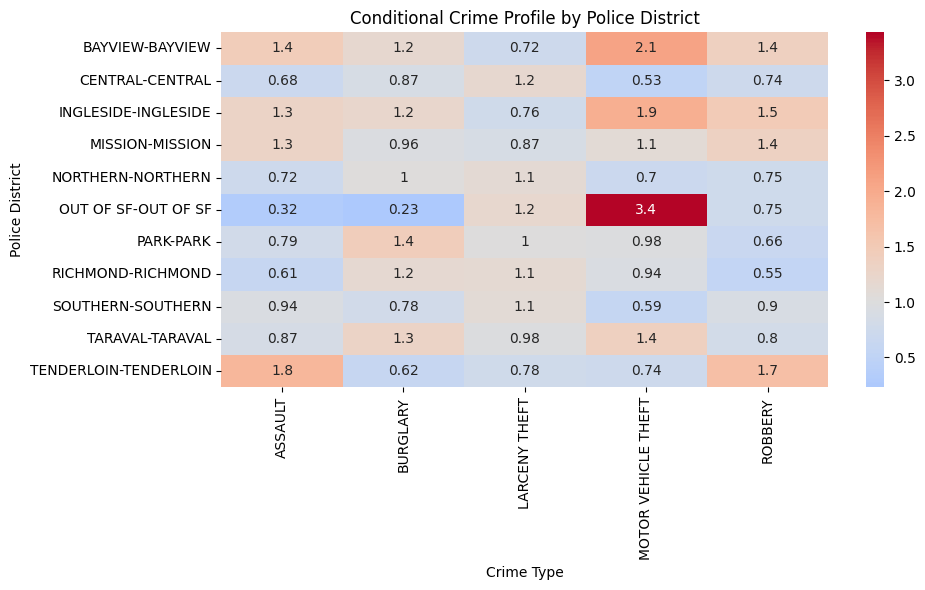

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(ratio, annot=True, cmap='coolwarm', center=1)

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Crime Type")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()


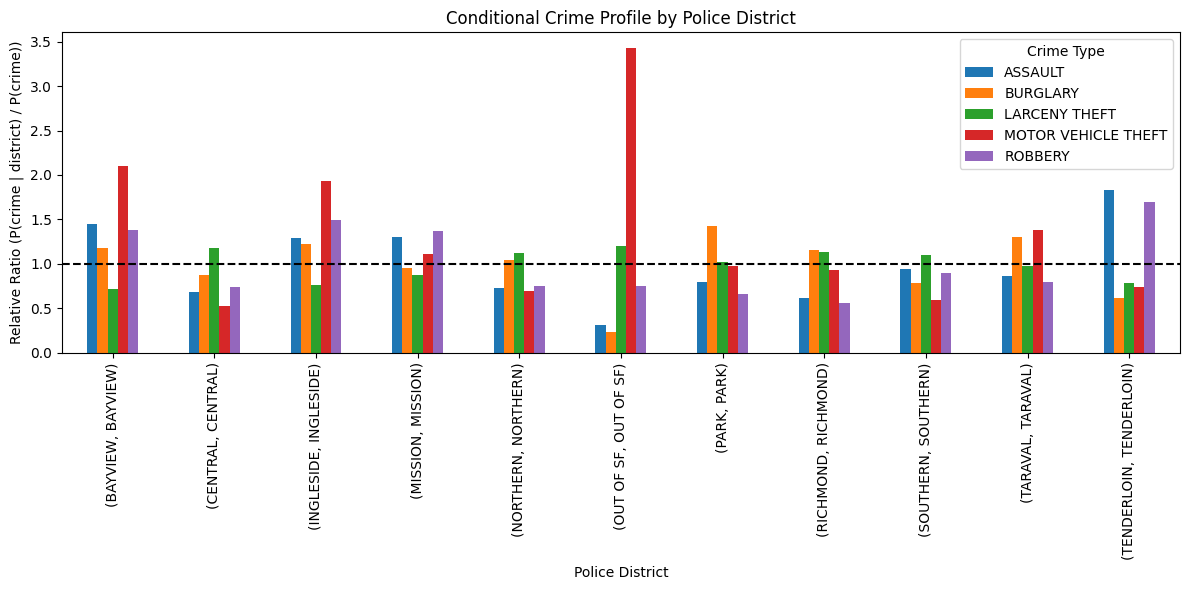

In [8]:



ratio.plot(kind='bar', figsize=(12,6))

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Police District")
plt.ylabel("Relative Ratio (P(crime | district) / P(crime))")
plt.axhline(1, color='black', linestyle='--')  # baseline
plt.legend(title="Crime Type")
plt.tight_layout()
plt.show()


Excerise 1.2:CRIME PROFILE BY POLICE DISTRICT
DISTRICT THAT STANDS OUT::TENDERLOIN
The tenderloin district stands out clearly in the conditional crime profile.
From the heatmap:
.Assault(1.8) is substantially over-represented
.Robbery(1.7) is also clearly over-represented
.Burglary(0.62) is under-represented
.Motor Vehicle Theft(0.74) is below the city average
.Larceny Theft(0.78) is slightly under-represented

INTERPRETATION::
The over-representation of assault and robbery in the Tenderloin likely reflects the district's unique social and geographic characteristics.The Tenderloin is a densely populated urban area with high pedestrain traffic, significant commerical activity, and active nightlife.Such environments increase opportunities for interpersonal interaction,which can elevate the likelihood of violent offenses.
Additionally,the district has long been associated with socioeconomic challenges,including higher levels of poverty and homelessness.These structural factors may contribute to elevated rates of certain types of violent crime.
In contrast,burglary and motor vehicle theft are under-represented relative to the city average.Thid suggests that property crimes involving residences or vehicles may be more prevalent in districts with more residential density or greater vehicle ownership, rather than in highly centralized urban areas like the Tenderloin.

The conditional crime profile demonstrates that crime composition varies substantially across police districts.The Tenderloin exhibits a distinct pattern characterized by over-representation of violent crimes and under-representation of certain property crimes.This highlights the importance of geographic and social context when analyzing urban crime patterns and shows that crime is not evenly distributed across space.

# Assignment 1.3: Visualizing Distributions
## Part A: Jitter Plot

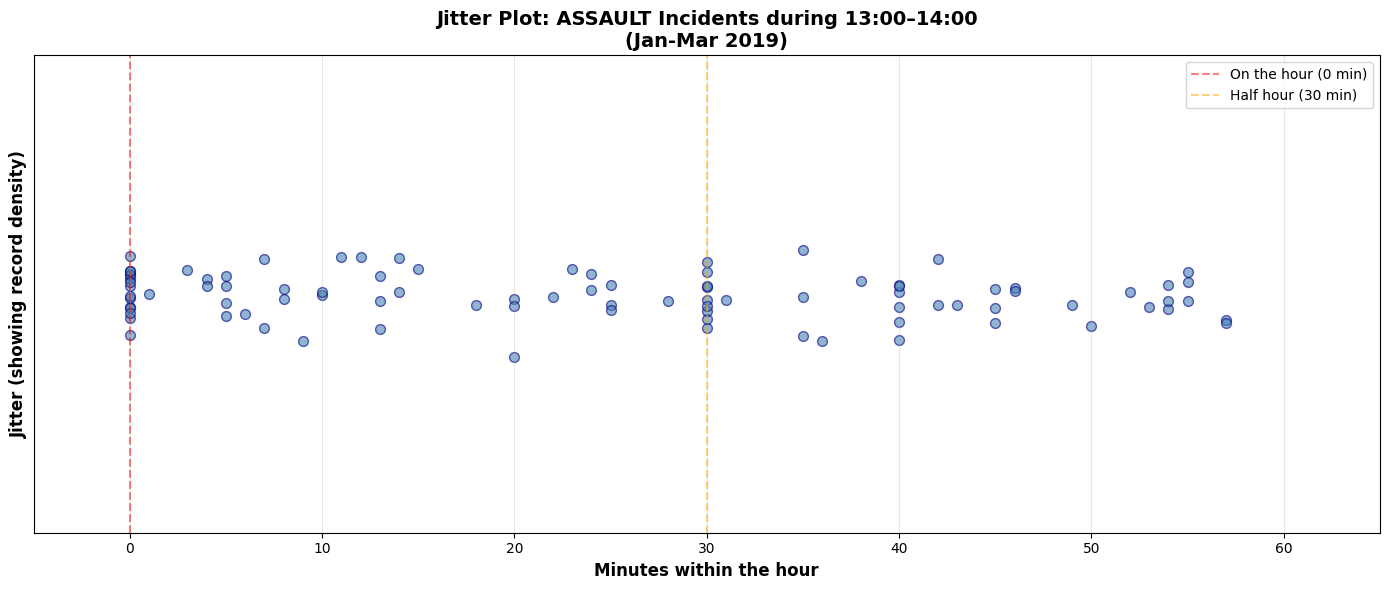

Total points plotted: 92
Incidents recorded at exactly 0 minutes: 15 (16.3%)


In [12]:
# Part A: Jitter Plot for ASSAULT (Jan-Mar 2019, 13:00–14:00)
import numpy as np
import matplotlib.pyplot as plt

# Filter for ASSAULT crime
crime_selected = "ASSAULT"
df_crime = df[df["cat_clean"] == crime_selected].copy()

# Select 3-month time window (Jan-Mar 2019)
df_time_window = df_crime[
    (df_crime["year"] == 2019) & 
    (df_crime["month"].isin([1, 2, 3]))
].copy()

# Filter for 13:00–14:00 hour
df_hour = df_time_window[df_time_window["hour"] == 13].copy()

# Extract minutes from Incident Time
df_hour["minute"] = df_hour["Incident Time"].str.split(":").str[1].astype(float)

# Create the jitter plot
fig, ax = plt.subplots(figsize=(14, 6))

# Add vertical jitter to reveal clustering
np.random.seed(42)
jitter = np.random.normal(0, 0.02, size=len(df_hour))

# Scatter plot with jitter
ax.scatter(df_hour["minute"], 
           np.ones(len(df_hour)) + jitter,
           alpha=0.6, s=50,
           edgecolors='navy',
           facecolors='steelblue')

# Formatting
ax.set_xlabel("Minutes within the hour", fontsize=12, fontweight='bold')
ax.set_ylabel("Jitter (showing record density)", fontsize=12, fontweight='bold')
ax.set_title(f"Jitter Plot: {crime_selected} Incidents during 13:00–14:00\n(Jan-Mar 2019)", 
             fontsize=14, fontweight='bold')
ax.set_xlim(-5, 65)
ax.set_ylim(0.8, 1.2)
ax.grid(True, alpha=0.3, axis='x')
ax.set_yticks([])

# Reference lines
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='On the hour (0 min)')
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Half hour (30 min)')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Key statistics
print(f"Total incidents plotted: {len(df_hour)}")
print(f"Incidents at hour boundary (0 min): {(df_hour['minute'] == 0).sum()} ({(df_hour['minute'] == 0).sum()/len(df_hour)*100:.1f}%)")

## Interpretation of Jitter Plot
The jitter plot shows the distribution of assault incidents within the hour 13:00–14:00 across January–March 2019. While incidents occur throughout the hour, there is a clear concentration at exactly 13:00 (minute 0), where 16.3% (15 out of 92 incidents) are recorded. This suggests a possible reporting bias due to time rounding by police officers.

Similarly, there appears to be a smaller concentration around 30 minutes, although it is much weaker than the spike at minute 0. This may again indicate rounding of time to 0 or 30 minutes for convenience when the exact time is uncertain.

Aside from these concentrations, incidents are relatively spread across the hour, and there is no extreme clustering beyond minute 0. Overall, while the data appear reasonably precise, the plot suggests potential rounding or recording bias in the reported incident times.

## Part B — Probability plot


ASSAULT:
  Total incidents: 223778
  Latitude mean: 37.7674
  Latitude std: 0.2932
  Latitude range: [37.7079, 90.0000]

LARCENY THEFT:
  Total incidents: 737302
  Latitude mean: 37.7758
  Latitude std: 0.3226
  Latitude range: [37.7078, 90.0000]

MOTOR VEHICLE THEFT:
  Total incidents: 52968
  Latitude mean: 37.7591
  Latitude std: 0.0260
  Latitude range: [37.7080, 37.8301]



ASSAULT:
  Total incidents: 223778
  Latitude mean: 37.7674
  Latitude std: 0.2932
  Latitude range: [37.7079, 90.0000]

LARCENY THEFT:
  Total incidents: 737302
  Latitude mean: 37.7758
  Latitude std: 0.3226
  Latitude range: [37.7078, 90.0000]

MOTOR VEHICLE THEFT:
  Total incidents: 52968
  Latitude mean: 37.7591
  Latitude std: 0.0260
  Latitude range: [37.7080, 37.8301]


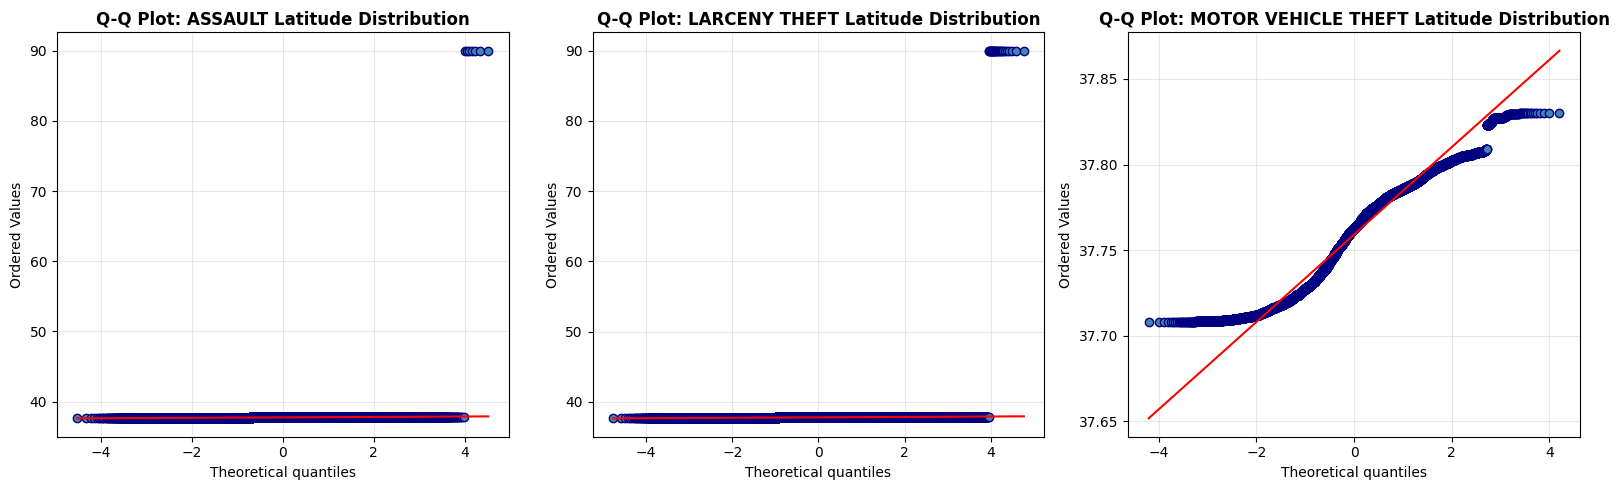

In [18]:
# Part B: Probability Plot (QQ Plot) for Latitude Distribution
from scipy import stats


crimes_for_qq = ["ASSAULT", "LARCENY THEFT", "MOTOR VEHICLE THEFT"]

# Create subplots for QQ plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, crime in enumerate(crimes_for_qq):
    # Filter data for the crime type
    crime_data = df[df["cat_clean"] == crime].copy()
    
    # Get latitude data   
    latitudes = crime_data["Latitude"].dropna().values
    
    print(f"\n{crime}:")
    print(f"  Total incidents: {len(latitudes)}")
    print(f"  Latitude mean: {latitudes.mean():.4f}")
    print(f"  Latitude std: {latitudes.std():.4f}")
    print(f"  Latitude range: [{latitudes.min():.4f}, {latitudes.max():.4f}]")
    
    # Create QQ plot 
    stats.probplot(latitudes, dist="norm", plot=axes[idx])
    
    # Change marker color to steelblue with navy edges
    lines = axes[idx].get_lines()
    if len(lines) > 0:
        lines[0].set_color('steelblue')
        lines[0].set_markerfacecolor('steelblue')
        lines[0].set_markeredgecolor('navy')
    
    axes[idx].set_title(f"Q-Q Plot: {crime} Latitude Distribution", fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation of Q-Q Plots

For Assault and Larceny Theft, there is a very strong deviation in the upper tail of the plots. This is caused by extreme latitude values of 90.0000, which are outside the geographic boundaries of San Francisco. Since latitude 90 corresponds to the North Pole, these values are clearly invalid and likely represent data entry errors or placeholder coordinates. These extreme values pull the distribution away from the reference line and make it clearly non-normal.

In contrast, the Motor Vehicle Theft distribution looks much cleaner. There are no extreme outliers such as latitude 90. The points still do not fall perfectly on the reference line, and the slight S-shaped pattern suggests the data are not perfectly normally distributed. However, this deviation appears to reflect natural geographic clustering within the city rather than data errors.

Overall, the plots show that crime latitudes are tightly concentrated within a narrow north–south range, which makes sense because San Francisco is geographically small. Since latitude values are bounded by the physical limits of the city, they are unlikely to follow a perfect normal distribution. The main takeaway is that some crime categories contain data quality issues, while others mainly reflect the natural geographic structure of crime in the city.

## Part C- Box plots of time of day

In [23]:
# Part C: Box Plots of Time-of-Day Distribution

# Prepare data for time-of-day analysis
time_of_day_data = []

for crime in focus_crimes:
    crime_data = df[df["cat_clean"] == crime].copy()
    # Extract hour from the data (already in 'hour' column)
    hours = crime_data["hour"].dropna().values
    
    for hour in hours:
        time_of_day_data.append({
            'Crime Type': crime,
            'Hour': hour
        })

time_df = pd.DataFrame(time_of_day_data)

print("Time-of-day statistics by crime type:")
print(time_df.groupby('Crime Type')['Hour'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))

Time-of-day statistics by crime type:
                      count       mean  median       std  min  max
Crime Type                                                        
ASSAULT              223886  12.799081    14.0  6.880445    0   23
BURGLARY             145490  12.189772    13.0  6.913857    0   23
LARCENY THEFT        764405  14.132239    15.0  6.158700    0   23
MOTOR VEHICLE THEFT   53655  14.092219    16.0  6.469322    0   23
ROBBERY               76370  13.085164    15.0  7.364133    0   23


C:\Users\Dell\AppData\Local\Temp\ipykernel_23120\1669254848.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=time_df, x='Crime Type', y='Hour', ax=ax1,
C:\Users\Dell\AppData\Local\Temp\ipykernel_23120\1669254848.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=time_df, x='Crime Type', y='Hour', ax=ax2,


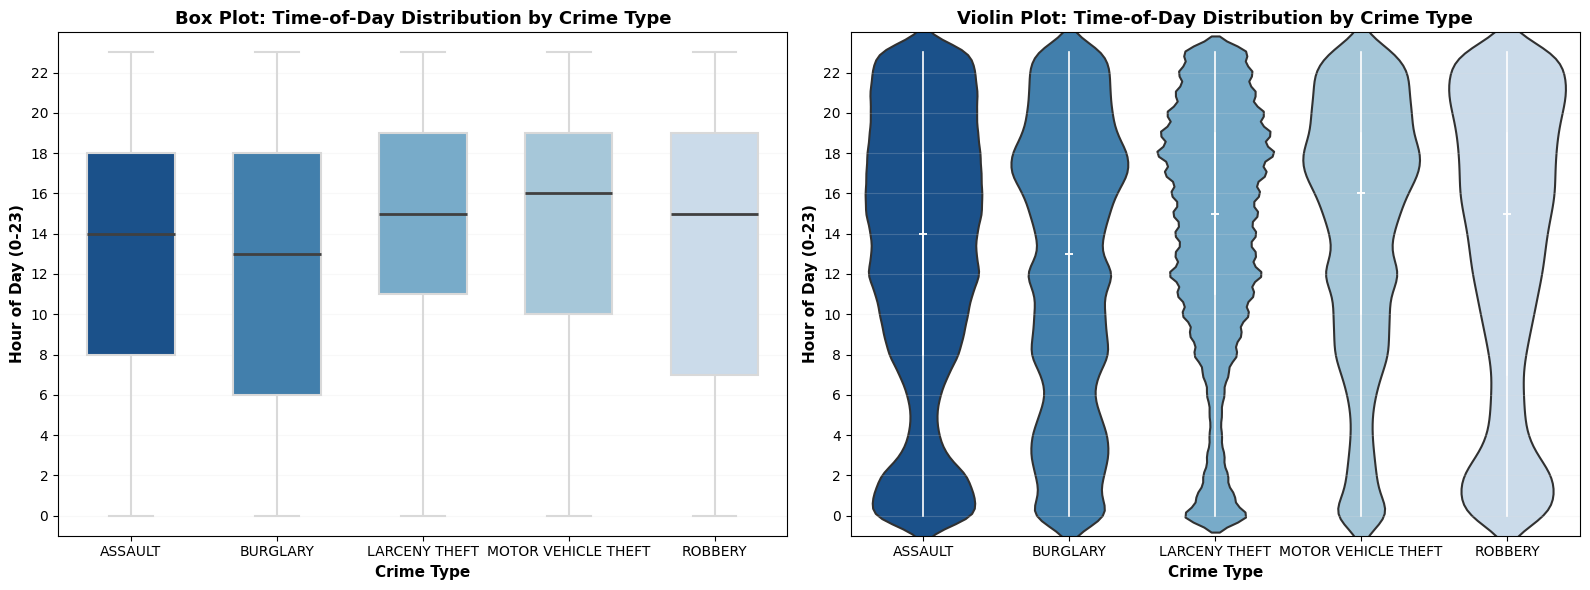

In [29]:
blue_palette = ['#08519c', '#3182bd', '#6baed6', '#9ecae1', '#c6dbef']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot (first visualization method)
sns.boxplot(data=time_df, x='Crime Type', y='Hour', ax=ax1, 
            palette=blue_palette, width=0.6,
            boxprops=dict(edgecolor='#d9d9d9', linewidth=1.5),
            whiskerprops=dict(color='#d9d9d9', linewidth=1.5),
            capprops=dict(color='#d9d9d9', linewidth=1.5),
            medianprops=dict(color='#404040', linewidth=2))
ax1.set_title('Box Plot: Time-of-Day Distribution by Crime Type', fontsize=13, fontweight='bold')
ax1.set_xlabel('Crime Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Hour of Day (0-23)', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.2, axis='y', color='#e0e0e0', linewidth=0.8)
ax1.set_ylim(-1, 24)
ax1.set_yticks(range(0, 24, 2))

# Violin plot 
sns.violinplot(data=time_df, x='Crime Type', y='Hour', ax=ax2, 
               palette=blue_palette, inner='box',
               linewidth=1.5)
ax2.set_title('Violin Plot: Time-of-Day Distribution by Crime Type', fontsize=13, fontweight='bold')
ax2.set_xlabel('Crime Type', fontsize=11, fontweight='bold')
ax2.set_ylabel('Hour of Day (0-23)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.2, axis='y', color='#e0e0e0', linewidth=0.8)
ax2.set_ylim(-1, 24)
ax2.set_yticks(range(0, 24, 2))

# Adjust inner box lines in violin plot to be white for better visibility
for line in ax2.get_lines():
    if line.get_color() != 'C0':  
        line.set_color('white')
        line.set_linewidth(1.2)

plt.tight_layout()
plt.show()



## Interpretation of Time-of-Day Box Plots and Violin Plots

When we look at the distribution of these five crime types, the most striking pattern is that they all tend to cluster around the middle of the day. Instead of showing a massive spike under the cover of darkness, the data indicates that the median time for these incidents falls between noon and 4 PM. This suggests that in a busy environment like San Francisco, crime tends to follow the flow of human activity: more people are out on the streets, in shops, or away from their homes during business hours, which creates more opportunities for both property crimes and personal altercations. For instance, burglary medians peak around 1 PM, when many homes are unoccupied, while larceny and vehicle thefts peak slightly later in the afternoon during high‑traffic periods.

One of the biggest challenges in graphing this data is the “midnight wrap‑around” problem. Because our clocks are circular but these graphs are linear, a crime that happens at 11:59 PM (hour 23) and one that happens at 12:01 AM (hour 0) appear at opposite ends of the chart, even though they are only two minutes apart. This can make a single late‑night peak look like two separate, disconnected clusters. While the box plots are useful for showing the “middle 50%” of the data at a glance, they struggle to convey where the data is most dense.

This is where the violin plots provide much better insight. Unlike the rigid boxes, the “bulges” in the violin plots show exactly where most incidents occur. They reveal that most of these crimes have a unimodal shape, meaning there is one clear, smooth hump in the middle of the day rather than multiple spikes. Interestingly, even for violent crimes like assault and robbery, the violin shapes do not show a hidden second peak at night instead, they confirm that the risk is fairly consistent and smoothly distributed throughout the active hours of the day. While robbery shows the most stretched out shape indicating it is less predictable than the others. Hence,the overall story remains the same in this dataset, crime is largely a daytime and early evening phenomenon.

